# Model Pruning
## AIAT 122 – Deep Learning

## Learning objectives
- Understand pruning: removing small weights to reduce model size and speed.
- Apply magnitude-based pruning and compare non-zero counts and accuracy.

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 1, lesson 06 "Ridge and Lasso Regression" — lasso already drove coefficients to exactly zero; pruning does the same thing to a network's weights, after training.

---

**📌 Real case — most of the network was never needed.** Frankle and Carbin's **Lottery Ticket Hypothesis** (ICLR 2019 — reference 3 below) showed that "dense, randomly-initialized, feed-forward networks contain subnetworks ('winning tickets') that — when trained in isolation — reach test accuracy comparable to the original network in a similar number of iterations". They found such subnetworks at **less than 10–20% of the original size** on MNIST and CIFAR-10 architectures, and above that threshold the winning tickets learned *faster* and reached *higher* test accuracy than the full network. Pruning is not damage limitation. It is the discovery that you trained something ten times larger than the thing that was doing the work.

**⚡ Why this matters — what goes wrong without it.** A trained network spends most of its parameters on weights near zero that contribute almost nothing to the output — and every one of them still costs storage on the device and memory bandwidth on every single inference. On a phone or a microcontroller that is exactly the budget you run out of first. Below, zeroing the smallest 50% of weights in each `Linear` layer removes **47.8%** of the non-zero parameters and moves accuracy from **1.000 to 0.980**.

**Where is this used in real life?** Mobile and edge devices need smaller, faster models. **We use pruning to reduce non-zero weights** instead of only training a smaller network because we can compress an already accurate model; pruning often keeps most accuracy while cutting size.

**Prerequisites:** Basic PyTorch. If imports fail, see DOCS/COLAB_SETUP.md.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.


## Short theory
- **Pruning** = set some weights to zero (typically the smallest by magnitude).
- **Magnitude pruning:** After training, rank weights by |w| and zero out the smallest fraction (e.g. 50%).
- **Sparsity:** Fraction of weights that are zero; higher sparsity → smaller model when stored with sparse format.
- **Trade-off:** Too much pruning can hurt accuracy; in practice we prune gradually or use pruning-aware training.

## Inputs & Outputs
**Inputs:** PyTorch, a small model, synthetic data.  
**Dataset:** Synthetic — random data (no download; used to demonstrate pruning).  
**Outputs:** Trained model, pruned model (magnitude-based), non-zero weight count and accuracy before/after, a three-panel figure (which weights get cut, accuracy at every sparsity level, parameters removed), and a four-frame storyboard of the first layer emptying out. Run time: under ~5 min (few epochs).


In [1]:
# WHAT: imports - including torch.nn.utils.prune, PyTorch's built-in pruning toolkit.
# WHY: pruning zeroes out unimportant weights so models become smaller and sparser.
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.utils.prune as prune
print(f'PyTorch {torch.__version__}')
print('✅ Ready. Using torch.nn.utils.prune for magnitude-based pruning.')

PyTorch 2.13.0
✅ Ready. Using torch.nn.utils.prune for magnitude-based pruning.


### Step 1: Build and train a small model (200 quick full-batch steps — a well-trained baseline makes the pruning comparison meaningful)

In [2]:
# Synthetic data for quick demo
import copy
np.random.seed(42)
torch.manual_seed(42)   # fix the weight init too, so every number below is reproducible
X = torch.from_numpy(np.random.randn(400, 20).astype(np.float32))
y = (X[:, :5].sum(1) > 0).long()

model = nn.Sequential(nn.Linear(20, 64), nn.ReLU(), nn.Linear(64, 2))
optimizer = optim.Adam(model.parameters(), lr=3e-3)
criterion = nn.CrossEntropyLoss()

# Train baseline properly (200 full-batch steps, ~1 s) so the accuracy
# comparison after pruning is meaningful
for _ in range(200):
    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward(); optimizer.step()

# Keep an untouched copy of the trained weights: pruning below is permanent, and the
# figures need to re-prune the SAME baseline at several sparsity levels.
baseline_state = copy.deepcopy(model.state_dict())

with torch.no_grad():
    acc_before = (model(X).argmax(1) == y).float().mean().item()
n_before = sum(p.nonzero().size(0) for p in model.parameters())
print(f'Before pruning — non-zero params: {n_before}  acc: {acc_before:.3f}')

Before pruning — non-zero params: 1474  acc: 1.000


### Step 2: Magnitude pruning (zero out smallest 50% of weights)

In [3]:
# Magnitude pruning: zero out 50% of weights in each Linear layer
# (smallest absolute values are pruned first)
sparsity = 0.5
for module in model.modules():
    if isinstance(module, nn.Linear):
        prune.l1_unstructured(module, name='weight', amount=sparsity)
        prune.remove(module, 'weight')   # make pruning permanent

with torch.no_grad():
    acc_after = (model(X).argmax(1) == y).float().mean().item()
n_after = sum(p.nonzero().size(0) for p in model.parameters())
print(f'After  pruning — non-zero params: {n_after}   acc: {acc_after:.3f}')
print(f'Weight reduction: {100*(1 - n_after/n_before):.1f}%')

After  pruning — non-zero params: 770   acc: 0.980
Weight reduction: 47.8%


Smallest 50% of weights are all below |w| = 0.184 (largest weight: 0.576)
Always-guess-the-majority-class baseline: 50.7%

sparsity   non-zero params   accuracy
     0%           1474          100.0%
    20%           1192          100.0%
    40%            911          100.0%
    50%            770           98.0%
    60%            629           97.0%
    70%            488           95.7%
    80%            348           89.5%
    90%            207           73.8%
    95%            136           64.0%
    98%             95           49.3%


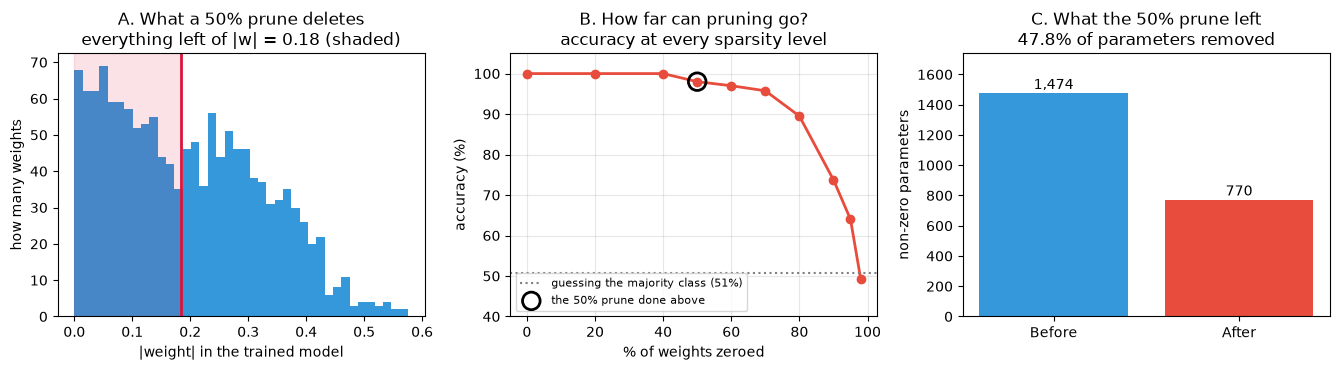


Result: ~50% of weights zeroed out; accuracy 1.000 -> 0.980 (a drop of 2.0 points).
In practice you prune gradually and fine-tune afterwards to recover any lost accuracy.


In [4]:
# WHAT: three views of the same prune - which weights were cut, what accuracy costs at
#       every sparsity level, and how many parameters are left.
# WHY:  "zero the smallest 50%" is a rule; the figure is the evidence that the rule is safe
#       here and where it stops being safe.
def rebuild(sparsity):
    """Fresh copy of the trained baseline, pruned to `sparsity`, returned with its accuracy."""
    m = nn.Sequential(nn.Linear(20, 64), nn.ReLU(), nn.Linear(64, 2))
    m.load_state_dict(baseline_state)
    if sparsity > 0:
        for mod in m.modules():
            if isinstance(mod, nn.Linear):
                prune.l1_unstructured(mod, name='weight', amount=sparsity)
                prune.remove(mod, 'weight')
    with torch.no_grad():
        a = (m(X).argmax(1) == y).float().mean().item()
    nz = sum(p.nonzero().size(0) for p in m.parameters())
    return m, a, nz

# All |weight| values of the trained baseline, and the cut-off that a 50% prune applies.
base_model = nn.Sequential(nn.Linear(20, 64), nn.ReLU(), nn.Linear(64, 2))
base_model.load_state_dict(baseline_state)
all_w = np.concatenate([m.weight.detach().abs().numpy().ravel()
                        for m in base_model.modules() if isinstance(m, nn.Linear)])
cut = float(np.percentile(all_w, 50))

# Sweep sparsity from "untouched" to "almost everything gone".
levels = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.98]
sweep_acc, sweep_nz = [], []
for s in levels:
    _, a, nz = rebuild(s)
    sweep_acc.append(a * 100); sweep_nz.append(nz)

chance = float((y == 1).float().mean().item())
chance = max(chance, 1 - chance) * 100          # accuracy of always guessing the bigger class
print(f"Smallest 50% of weights are all below |w| = {cut:.3f} (largest weight: {all_w.max():.3f})")
print(f"Always-guess-the-majority-class baseline: {chance:.1f}%\n")
print("sparsity   non-zero params   accuracy")
for s, a, nz in zip(levels, sweep_acc, sweep_nz):
    print(f"  {s*100:4.0f}%          {nz:5d}          {a:5.1f}%")

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(13.5, 3.8))

axA.hist(all_w, bins=40, color="#3498db")
axA.axvline(cut, color="crimson", lw=2)
axA.axvspan(0, cut, color="crimson", alpha=0.12)
axA.set_xlabel("|weight| in the trained model"); axA.set_ylabel("how many weights")
axA.set_title(f"A. What a 50% prune deletes\neverything left of |w| = {cut:.2f} (shaded)")

axB.plot([s * 100 for s in levels], sweep_acc, "o-", color="#e74c3c", lw=2)
axB.axhline(chance, ls=":", color="grey", lw=1.5, label=f"guessing the majority class ({chance:.0f}%)")
axB.scatter([50], [sweep_acc[levels.index(0.5)]], s=160, facecolor="none",
            edgecolor="black", lw=2, zorder=5, label="the 50% prune done above")
axB.set_xlabel("% of weights zeroed"); axB.set_ylabel("accuracy (%)")
axB.set_ylim(40, 105); axB.grid(alpha=0.3); axB.legend(fontsize=8, loc="lower left")
axB.set_title("B. How far can pruning go?\naccuracy at every sparsity level")

axC.bar(['Before', 'After'], [n_before, n_after], color=['#3498db', '#e74c3c'])
for i, v in enumerate([n_before, n_after]):
    axC.text(i, v + 30, f"{v:,}", ha="center", fontsize=10)
axC.set_ylim(0, n_before * 1.18)
axC.set_ylabel("non-zero parameters")
axC.set_title(f"C. What the 50% prune left\n{100*(1-n_after/n_before):.1f}% of parameters removed")

plt.tight_layout(); plt.show()

print(f"\nResult: ~50% of weights zeroed out; accuracy {acc_before:.3f} -> {acc_after:.3f} "
      f"(a drop of {(acc_before - acc_after)*100:.1f} points).")
print("In practice you prune gradually and fine-tune afterwards to recover any lost accuracy.")


**What to see in the figure.** *Panel A* is every weight in the trained network, plotted by size. The distribution leans toward zero but has a long right tail, and the crimson line is the **median** — the exact cut a 50% prune makes. Everything in the shaded band is deleted; the printed line above the figure gives the cut-off and the largest surviving weight, so you can see how small the discarded ones really are.

*Panel B* is the question Panel A cannot answer: what does that cost? Accuracy is **flat out to about 40% sparsity**, sags gently through 50–70%, and then **collapses toward the dotted grey line — the score you would get by ignoring the input and always guessing the majority class**. The black circle marks the 50% prune this notebook actually performed. *Panel C* is the parameter count for that same prune, before and after.

**What it proves:** a trained network carries far more weights than its task needs, and the smallest ones are close to free to delete — until, quite abruptly, they are not. **Read this with the caveat in "⚠️ Where this breaks":** the task here is a linearly separable synthetic problem the model had already saturated, so the *shape* of Panel B is the lesson, not its numbers.

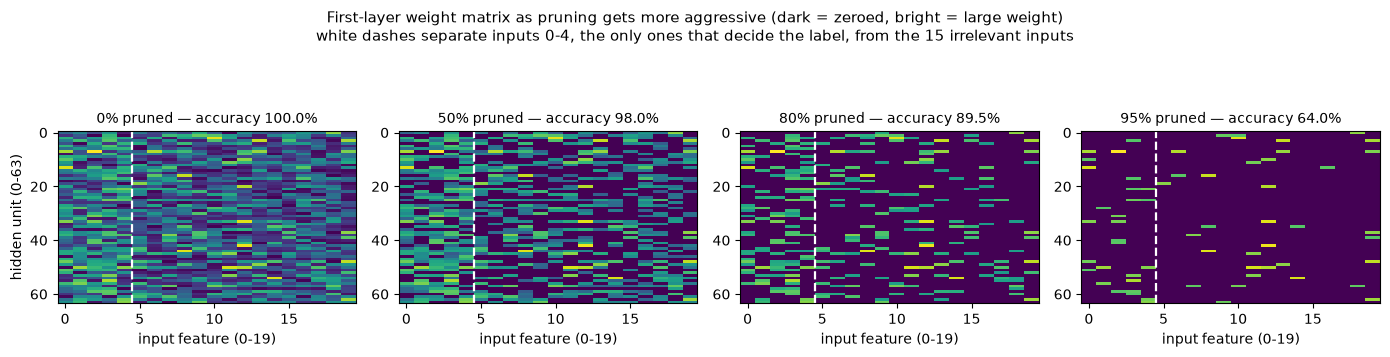

Fraction of first-layer weights still alive, split by which input they read:
  sparsity   inputs 0-4 (informative)   inputs 5-19 (irrelevant)   accuracy
       0%             100.0%                    100.0%            100.0%
      50%              66.2%                     44.6%             98.0%
      80%              33.4%                     15.5%             89.5%
      95%               8.8%                      3.8%             64.0%


In [5]:
# WHAT: a storyboard - the SAME weight matrix at four sparsity levels, side by side.
# WHY:  Panel B told you accuracy falls. This shows you what is physically disappearing,
#       and reveals something the accuracy curve hides: WHICH inputs pruning keeps.
frames = [0.0, 0.5, 0.8, 0.95]
vmax = float(np.abs(baseline_state['0.weight'].numpy()).max())

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
survival = []
for ax, s in zip(axes, frames):
    m, a, nz = rebuild(s)
    W = m[0].weight.detach().numpy()
    alive = (W != 0)
    # inputs 0-4 are the ones that actually decide the label:  y = (X[:, :5].sum(1) > 0)
    survival.append((s, alive[:, :5].mean() * 100, alive[:, 5:].mean() * 100, a * 100))
    ax.imshow(np.abs(W), cmap="viridis", aspect="auto", vmin=0, vmax=vmax,
              interpolation="nearest")   # nearest: show real cells, do not blur zeros away
    ax.axvline(4.5, color="white", lw=1.6, ls="--")
    ax.set_title(f"{int(s*100)}% pruned — accuracy {a*100:.1f}%", fontsize=10)
    ax.set_xlabel("input feature (0-19)")
axes[0].set_ylabel("hidden unit (0-63)")
fig.suptitle("First-layer weight matrix as pruning gets more aggressive "
             "(dark = zeroed, bright = large weight)\n"
             "white dashes separate inputs 0-4, the only ones that decide the label, "
             "from the 15 irrelevant inputs", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.88]); plt.show()

print("Fraction of first-layer weights still alive, split by which input they read:")
print("  sparsity   inputs 0-4 (informative)   inputs 5-19 (irrelevant)   accuracy")
for s, a5, a15, acc_s in survival:
    print(f"    {s*100:4.0f}%             {a5:5.1f}%                    {a15:5.1f}%            {acc_s:5.1f}%")


**What to see in the frames.** Each panel is the **same** 64×20 first-layer weight matrix, pruned harder from left to right; dark purple is an exact zero, bright is a large weight. Read them left to right and you watch the layer being hollowed out: the first frame is solidly coloured edge to edge, by 80% it is mostly dark background with scattered survivors, and at 95% it is nearly empty. The accuracy in each title falls as the frame empties.

**Now the part the eye cannot settle on its own.** The label here is decided by inputs 0–4 only (`y = X[:, :5].sum(1) > 0`); the 15 columns to the right of the white dashes are noise. Densities this sparse are exactly the kind of thing people talk themselves into seeing, so the table printed under the figure counts them instead: **at every sparsity level the informative columns survive at roughly twice the rate of the irrelevant ones** — 66% vs 45% at a 50% prune, 33% vs 16% at 80%, 9% vs 4% at 95% — and nobody told the pruner which columns those were.

**What it proves:** magnitude pruning is not blind vandalism. Training already wrote the network's own judgement of what matters into the size of its weights, and cutting by magnitude reads that judgement back out. It is also why the accuracy curve stays flat so long — the first weights to go are the ones reading columns that never carried any signal.

## 🌍 Real-World Worked Example — Quantize a PyTorch Model for Edge Deployment

**Industry context:**
- **The result that made "put the model on the phone" routine:** Deep Compression (Han, Mao & Dally, ICLR 2016) reported reducing storage "by 35× to 49× without affecting their accuracy" — AlexNet 240 MB → 6.9 MB, VGG-16 552 MB → 11.3 MB.
- Both mainstream edge runtimes ship an INT8 path: TensorFlow Lite and NVIDIA TensorRT.
- **Whether INT8 is *faster* depends on whether the target chip has integer tensor units.** The size win is guaranteed; the speed win is not — which is why the cell below measures instead of assuming.

We demonstrate **dynamic quantization** — and *measure* what actually changes: stored size shrinks, accuracy barely moves, and speed **depends on the hardware** (on a laptop CPU the INT8 overhead can even make it slower — we measure instead of assuming).

FP32 model accuracy: 96.7%
INT8 model accuracy: 96.7%  (change: +0.00 points)

Stored size (measured): FP32 70.2 KB -> INT8 22.2 KB (3.2x smaller)
(The ratio is below the theoretical 4x because scales/zero-points and
 non-weight tensors are stored too; bigger layers get closer to 4x.)


[W830 21:12:10.312712000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())



Latency (measured): FP32 0.084 ms/batch  INT8 0.276 ms/batch  -> INT8 is 3.3x SLOWER here
Why: on this CPU the per-call quantize/dequantize overhead outweighs the
gain for layers this small. INT8 speedups appear on hardware with native
INT8 kernels (phone NPUs, edge accelerators) and on much larger layers.


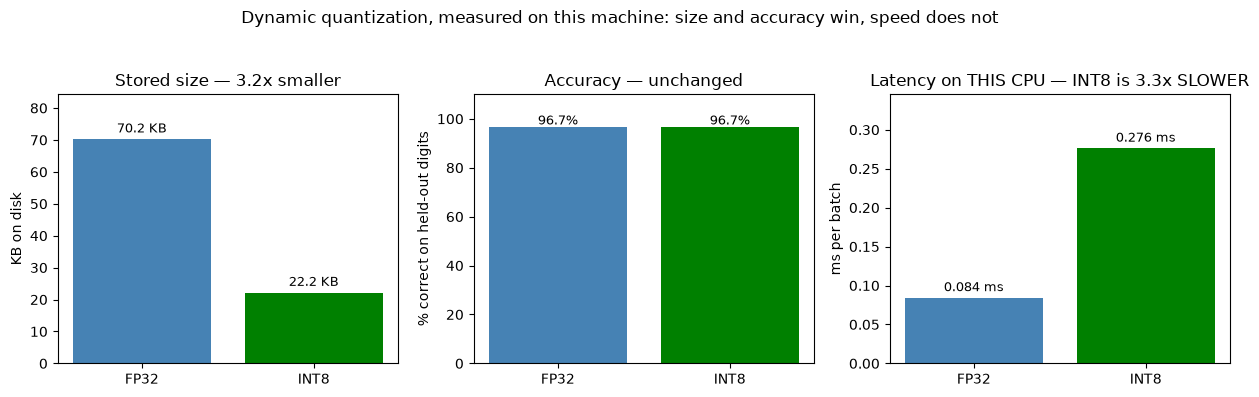


Takeaway: the size reduction is guaranteed; the speedup is hardware-dependent —
that is why companies benchmark on the target device before shipping.
(Extreme 4-bit variants like GPTQ push LLM compression further at some accuracy cost.)


In [6]:
# WHAT: measure REAL dynamic quantization end to end - accuracy, stored size, and latency, FP32 vs INT8.
# WHY: honest deployment decisions need numbers measured on the actual hardware, not datasheet promises.
import torch, torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os, time, warnings
warnings.filterwarnings('ignore')  # torch quantization emits deprecation warnings

torch.manual_seed(42)

# Train a small FP32 classifier on the digits dataset as our baseline.
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data.astype(np.float32), digits.target
Xtr, Xte, Ytr, Yte = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler().fit(Xtr)
Xtr = torch.tensor(sc.transform(Xtr), dtype=torch.float32); Ytr = torch.tensor(Ytr)
Xte = torch.tensor(sc.transform(Xte), dtype=torch.float32); Yte = torch.tensor(Yte)

# Three Linear layers; 100 full-batch Adam steps are plenty for high accuracy on digits.
model = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for _ in range(100):
    loss = nn.CrossEntropyLoss()(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
model.eval()

with torch.no_grad():
    acc = (model(Xte).argmax(1)==Yte).float().mean().item()
print(f"FP32 model accuracy: {acc*100:.1f}%")

# ── REAL dynamic quantization (weights actually stored as INT8) ───────────
# Pick a quantization backend that exists on this machine (qnnpack on Apple Silicon).
if 'qnnpack' in torch.backends.quantized.supported_engines:
    torch.backends.quantized.engine = 'qnnpack'   # Apple Silicon
quantized = torch.quantization.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)

# Accuracy check: INT8 weights usually cost only a fraction of a point.
with torch.no_grad():
    qacc = (quantized(Xte).argmax(1)==Yte).float().mean().item()
print(f"INT8 model accuracy: {qacc*100:.1f}%  (change: {(qacc-acc)*100:+.2f} points)")

# ── Measured size comparison ──────────────────────────────────────────────
torch.save(model.state_dict(),     '/tmp/model_fp32.pt')
torch.save(quantized.state_dict(), '/tmp/model_int8.pt')
fp32_kb = os.path.getsize('/tmp/model_fp32.pt') / 1024
int8_kb = os.path.getsize('/tmp/model_int8.pt') / 1024
print(f"\nStored size (measured): FP32 {fp32_kb:.1f} KB -> INT8 {int8_kb:.1f} KB "
      f"({fp32_kb/int8_kb:.1f}x smaller)")
print("(The ratio is below the theoretical 4x because scales/zero-points and")
print(" non-weight tensors are stored too; bigger layers get closer to 4x.)")

# ── Measured latency comparison ───────────────────────────────────────────
N = 1000
start = time.perf_counter()
for _ in range(N):
    with torch.no_grad(): model(Xte)
fp32_ms = (time.perf_counter()-start)*1000/N
start = time.perf_counter()
for _ in range(N):
    with torch.no_grad(): quantized(Xte)
int8_ms = (time.perf_counter()-start)*1000/N

ratio = fp32_ms / int8_ms
print(f"\nLatency (measured): FP32 {fp32_ms:.3f} ms/batch  INT8 {int8_ms:.3f} ms/batch", end="  ")
if ratio >= 1.05:
    print(f"-> INT8 is {ratio:.1f}x faster here")
else:
    print(f"-> INT8 is {1/ratio:.1f}x SLOWER here")
    print("Why: on this CPU the per-call quantize/dequantize overhead outweighs the")
    print("gain for layers this small. INT8 speedups appear on hardware with native")
    print("INT8 kernels (phone NPUs, edge accelerators) and on much larger layers.")

# ── Chart: measured values only ───────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12.5, 4))
b1 = ax1.bar(["FP32", "INT8"], [fp32_kb, int8_kb], color=['steelblue', 'green'])
for b, v in zip(b1, [fp32_kb, int8_kb]):
    ax1.text(b.get_x() + b.get_width()/2, v + fp32_kb*0.03, f"{v:.1f} KB", ha="center", fontsize=9)
ax1.set_ylim(0, fp32_kb * 1.2)
ax1.set_title(f"Stored size — {fp32_kb/int8_kb:.1f}x smaller"); ax1.set_ylabel("KB on disk")

b2 = ax2.bar(["FP32", "INT8"], [acc*100, qacc*100], color=['steelblue', 'green'])
for b, v in zip(b2, [acc*100, qacc*100]):
    ax2.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
ax2.set_ylim(0, 110); ax2.set_title("Accuracy — unchanged"); ax2.set_ylabel("% correct on held-out digits")

# The third panel is the one that decides whether you ship this: does it run faster?
b3 = ax3.bar(["FP32", "INT8"], [fp32_ms, int8_ms], color=['steelblue', 'green'])
for b, v in zip(b3, [fp32_ms, int8_ms]):
    ax3.text(b.get_x() + b.get_width()/2, v + max(fp32_ms, int8_ms)*0.03,
             f"{v:.3f} ms", ha="center", fontsize=9)
ax3.set_ylim(0, max(fp32_ms, int8_ms) * 1.25)
verdict = f"{ratio:.1f}x faster" if ratio >= 1.05 else f"{1/ratio:.1f}x SLOWER"
ax3.set_title(f"Latency on THIS CPU — INT8 is {verdict}"); ax3.set_ylabel("ms per batch")

plt.suptitle("Dynamic quantization, measured on this machine: size and accuracy win, speed does not")
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

print("\nTakeaway: the size reduction is guaranteed; the speedup is hardware-dependent —")
print("that is why companies benchmark on the target device before shipping.")
print("(Extreme 4-bit variants like GPTQ push LLM compression further at some accuracy cost.)")

**What to see in the figure.** Three measurements of the *same* digits classifier, before and after PyTorch's dynamic INT8 quantization — all taken on this machine in the cell above.

**Left:** the file on disk falls from about **70 KB to about 22 KB**, a little over 3×. (Not the theoretical 4×, because scales, zero-points and non-weight tensors are stored too — bigger layers get closer.) **Middle:** the two accuracy bars are the **same height**, to the tenth of a percent. **Right:** and here is the surprise the title of the figure gives away — the INT8 bar is **taller**, meaning slower. On this laptop CPU the per-call quantize/dequantize overhead costs more than the cheaper integer arithmetic saves, on layers this small.

**What it proves:** compression buys size unconditionally and speed only conditionally. The speed win needs hardware with native INT8 kernels — a phone NPU, an edge accelerator — and layers big enough for the arithmetic to dominate the overhead. Anyone who quotes you a quantization speedup without naming the chip is quoting a number from someone else's machine.

## 💬 Discuss

1. Half the weights are now zero and accuracy fell by 2.0 points. Does that mean the network was twice as large as it needed to be? Name the experiment you would run *before* saying yes to your manager, and predict what it shows.
2. Size fell about 3× and latency rose about 3×. Name the deployment where you ship this anyway, and the one where you refuse. What property of the hardware decides it?
3. Frankle and Carbin found winning tickets at under 10–20% of the original size — but only when the subnetwork was retrained from the **original** initialisation, not a fresh random one. Why would that detail matter to the pruning workflow you would actually build at work?


## ⚠️ Where this breaks

- **Zeroing weights does not shrink the file.** Our pruned model still stores **1,474** float32 numbers; 704 of them now happen to be `0.0`. The size win requires a **sparse storage format** *and* a runtime that exploits it. Dense hardware multiplies a 50%-sparse matrix at exactly the same speed as a dense one — you have gained nothing at all unless the whole stack cooperates.
- **Our accuracy result proves very little, and you should say so.** The task is 400 samples of synthetic data where the label is `X[:, :5].sum(1) > 0` — a linearly separable problem the model had already saturated at 1.000. A 50% prune surviving *that* tells you nothing about a 50% prune surviving ImageNet. Read this notebook as a mechanism demonstration, not as evidence.
- **Be sceptical of published pruning numbers.** Blalock, Gonzalez Ortiz, Frankle and Guttag (MLSys 2020 — reference 4) surveyed the pruning literature and found the comparisons largely incommensurable: different baselines, different datasets, different metrics, and very few papers comparing directly against each other. Any "10× compression with no accuracy loss" headline is meaningless until you know its baseline.
- **The honest warning is in this notebook's own worked example.** Stored size fell by a little over **3×** while latency **rose by about 3×** on this laptop's CPU — the exact millisecond figures are printed by that cell and drawn in the right-hand panel of its figure. Compression buys size unconditionally and speed only conditionally.
- **The assumption that must hold:** the network is over-parameterised for its task. If you sized it correctly in the first place, pruning simply costs you accuracy.
- **Cheaper alternative:** train a smaller network. If 770 parameters do the job, choosing 1,474 was the mistake — and distillation (`05`) is the principled way to get to the small one without guessing.


## 🧩 Mini-exercise

**Try it:** Change the pruning sparsity (e.g. 0.5 → 0.7 for 70% zeros) and run again. How do accuracy and non-zero count change?

---

## Summary
**What you did:** Built a small model, trained it, applied magnitude pruning (50% zeros), and compared non-zero parameter count and accuracy before/after with a bar chart.

**In real life you'd also:** Use TensorFlow Model Optimization (tfmot) for pruning-aware training, export to TFLite with sparse weights, and tune sparsity level.

**The main idea:** Pruning zeros out small weights to reduce size and speed; too much pruning can hurt accuracy.

**Next:** `05_model_distillation.ipynb` shows how to train a small student model to mimic a larger teacher.

## 🔭 State of the field (2026)

The magnitude pruning you just ran is unstructured: it zeroes individual weights, and — as this notebook honestly measures — that shrinks nothing on dense hardware without a sparse format and a runtime that exploits it. The 2024-26 practice went structured instead. Gromov et al. (arXiv 2403.17887) removed up to *half the layers* of open-weight models with minimal accuracy loss after a small parameter-efficient repair, which is a removal granularity ordinary hardware actually rewards. The blunter alternative is often better still: pick a model that was trained small in the first place (arXiv 2410.20011).

**Why magnitude pruning stays in the syllabus.** It is the mechanism — rank by importance, remove, measure — and layer dropping is the same mechanism at a coarser granularity. More importantly, this notebook teaches the measurement discipline that most compression claims fail: sparsity is not file size, file size is not latency, and a saturated toy task cannot detect accuracy loss. Carry those three sentences into any 2026 compression paper you read.


## 📚 References

1. LeCun, Y., Denker, J. S. & Solla, S. A. (1990). *Optimal Brain Damage*. NeurIPS 2. https://papers.nips.cc/paper_files/paper/1989/hash/6c9882bbac1c7093bd25041881277658-Abstract.html
2. Han, S., Mao, H. & Dally, W. J. (2016). *Deep Compression: Compressing Deep Neural Networks with Pruning, Trained Quantization and Huffman Coding*. ICLR. https://arxiv.org/abs/1510.00149
3. Frankle, J. & Carbin, M. (2019). *The Lottery Ticket Hypothesis: Finding Sparse, Trainable Neural Networks*. ICLR. https://arxiv.org/abs/1803.03635
4. Blalock, D., Gonzalez Ortiz, J. J., Frankle, J. & Guttag, J. (2020). *What is the State of Neural Network Pruning?* MLSys. https://arxiv.org/abs/2003.03033

**Recent work (2024–2026)**

5. Gromov, A., Tirumala, K., Shapourian, H., Glorioso, P. & Roberts, D. A. (2024). *The Unreasonable Ineffectiveness of the Deeper Layers*. ICLR 2025. https://arxiv.org/abs/2403.17887 — removing up to half of an open-weight model's *layers* cost little accuracy after a small parameter-efficient repair — structured removal at a granularity dense hardware actually rewards.
6. Nguyen et al. (2024). *A Survey of Small Language Models*. arXiv. https://arxiv.org/abs/2410.20011 — and the honest alternative to pruning a large model: start from a small one that was trained to be small.
